## Jack’s Car Rental — Original Problem (Figure 4.2)

Jack manages two car rental locations. At the end of each day, he can move cars between them overnight to meet the next day’s demand. Each rental earns **$10**, while moving a car costs **$2**.

The state is $(n_1, n_2)$, the number of cars at locations 1 and 2 before the overnight move. An action $a > 0$ moves cars from location 1 to location 2; $a < 0$ moves them in the opposite direction. At most **5 cars** can be moved per night, and each location can hold at most **20 cars**.

Rental requests and returns are independent Poisson random variables:

| Location | Mean daily requests | Mean daily returns |
|---|---:|---:|
| 1 | 3 | 3 |
| 2 | 4 | 2 |

A rental request is fulfilled only when a car is available. Returned cars become available the following day. Cars exceeding a location’s 20-car capacity leave the system. The discount factor is $\gamma = 0.9$.

**What the figure shows:** Policy iteration starts with $\pi_0$, which never moves cars. Each policy panel shows the number of cars to move for every state. The successive policies $\pi_1, \pi_2, \pi_3,$ and $\pi_4$ result from repeated policy evaluation and improvement. The final policy $\pi_4$ is optimal; the last panel shows its state-value function $v_*$, the expected discounted future return from each state.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np
from scipy.stats import poisson

MAX_CARS = 20
MAX_MOVE = 5
RENTAL_REWARD = 10.0
TRANSFER_COST = 2.0
DISCOUNT = 0.9
REQUEST_RATES = (3, 4)
RETURN_RATES = (3, 2)

In [ ]:
def capped_poisson(rate, capacity):
    """
    Probabilities for min(Poisson(rate), capacity), including the full tail.
    rate = Mean requests per day: 3 at location 1 or 4 at location 2; 
           Mean returns per day: 3 at location 1 or 2 at location 2
    capacity = Cars available to rent at that location
               Empty spaces remaining after rentals, up to the 20-car limit
    """
    
    if capacity == 0:
        return np.array([1.0])
    probs = poisson.pmf(np.arange(capacity + 1), rate)
    probs[-1] = poisson.sf(capacity - 1, rate)
    return probs

In [ ]:
def build_location(request_rate, return_rate):
    """
    Rental rewards and daily transitions for one location, for 0..20 cars.
    """

    reward = np.zeros(MAX_CARS + 1)
    transition = np.zeros((MAX_CARS + 1, MAX_CARS + 1))
    
    for available in range(MAX_CARS + 1):
        
        # Customers requesting more cars than available rent only available cars.
        for rented, rental_probability in enumerate(capped_poisson(request_rate, available)):
            reward[available] += RENTAL_REWARD * rented * rental_probability
            remaining = available - rented
            
            # Returns in excess of the 20-car capacity leave the problem.
            for returned, return_probability in enumerate(capped_poisson(return_rate, MAX_CARS - remaining)):
                transition[available, remaining + returned] += (rental_probability * return_probability)
    
    assert np.allclose(transition.sum(axis=1), 1.0)
    return reward, transition

In [ ]:
def possible_moves(n1, n2):
    """
    Only transfer cars that exist and can fit at the other location.
    n1 and n2 are the numbers of cars at location 1 and location 2
    """

    minimum = max(-MAX_MOVE, -n2, n1 - MAX_CARS)
    maximum = min(MAX_MOVE, n1, MAX_CARS - n2)
    
    return range(minimum, maximum + 1)

In [ ]:
def policy_iteration(tolerance=1e-9):
    """
    Solve the *original* problem and retain policies π0 through π4.
    """

    reward1, transition1 = build_location(REQUEST_RATES[0], RETURN_RATES[0])
    reward2, transition2 = build_location(REQUEST_RATES[1], RETURN_RATES[1])
    values = np.zeros((MAX_CARS + 1, MAX_CARS + 1))
    policy = np.zeros((MAX_CARS + 1, MAX_CARS + 1), dtype=int)
    history = [policy.copy()]
    sweeps_per_policy = []

    def post_transfer_value(value_function):
        # Independent locations: E[V(next state)] = T1 @ V @ T2.T.
        return (reward1[:, None] + reward2[None, :] + DISCOUNT * (transition1 @ value_function @ transition2.T))

    def q(n1, n2, move, post_transfer):
        return (post_transfer[n1 - move, n2 + move]- TRANSFER_COST * abs(move))

    for _ in range(100):
        # Evaluate the current policy by synchronous Bellman expectation sweeps.
        for sweep in range(10000):
            post_transfer = post_transfer_value(values)
            updated = np.empty_like(values)
            for n1 in range(MAX_CARS + 1):
                for n2 in range(MAX_CARS + 1):
                    updated[n1, n2] = q(n1, n2, policy[n1, n2], post_transfer)
            difference = np.max(np.abs(updated - values))
            values = updated
            if difference < tolerance:
                break
        else:
            raise RuntimeError("Policy evaluation did not converge")
        sweeps_per_policy.append(sweep + 1)

        # Improve; retain the current action if it ties for best.
        post_transfer = post_transfer_value(values)
        stable = True
        for n1 in range(MAX_CARS + 1):
            for n2 in range(MAX_CARS + 1):
                old_move = policy[n1, n2]
                moves = list(possible_moves(n1, n2))
                scores = np.array([q(n1, n2, move, post_transfer) for move in moves])
                if scores.max() > scores[moves.index(old_move)] + 1e-10:
                    policy[n1, n2] = moves[int(scores.argmax())]
                    stable = False
        if stable:
            return policy, values, history, sweeps_per_policy
        history.append(policy.copy())
    raise RuntimeError("Policy iteration did not converge")

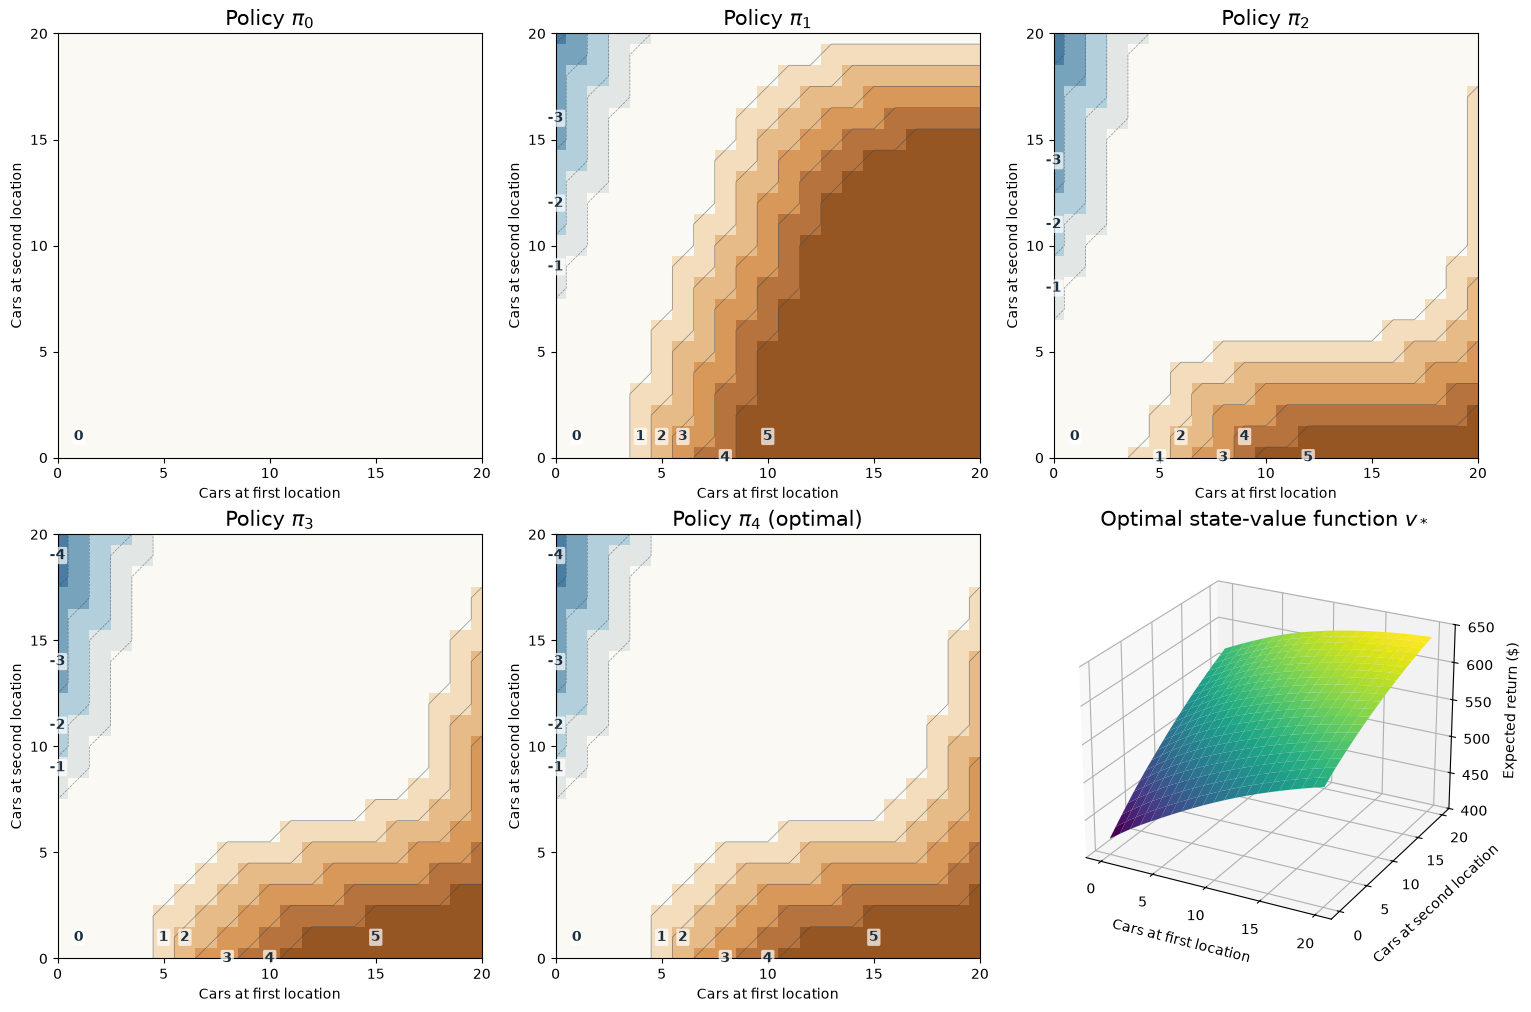

Evaluation sweeps: [235, 201, 189, 154, 81]
At (10, 10): π* = 0 , v* = 574.948


In [ ]:
def main():
    policy, values, history, sweeps = policy_iteration()
    assert len(history) == 5, "Expected policies π₀ through π₄"
    assert np.array_equal(policy, history[-1])

    cars = np.arange(21)
    x, y = np.meshgrid(cars, cars, indexing="ij")
    # Match the book's arrangement: π₀ π₁ π₂ / π₃ π₄ v₄.
    fig = plt.figure(figsize=(15, 10), layout="constrained")
    colors = ListedColormap([
        "#355c80", "#497da2", "#78a3bd", "#b2cfdb", "#e2e7e5",
        "#faf9f3", "#f3ddbd", "#e7bb87", "#d7985a", "#b7733d", "#955623",
    ])
    norm = BoundaryNorm(np.arange(-5.5, 6.5, 1), colors.N)
    for k, p in enumerate(history):
        ax = fig.add_subplot(2, 3, k + 1)
        z = p.T
        ax.imshow(z, origin="lower", extent=(-.5, 20.5, -.5, 20.5), cmap=colors, norm=norm, interpolation="nearest")
        # Integer labels inside policy regions, like the textbook figure.
        levels = np.arange(-5, 6)
        ax.contour(x, y, p, levels=levels - .5, colors="#354454", linewidths=.48, alpha=.6)
        ax.set_title(rf"Policy $\pi_{k}$" + (" (optimal)" if k == 4 else ""), fontsize=15)
        ax.set_xlabel("Cars at first location")
        ax.set_ylabel("Cars at second location")
        ax.set_xticks([0, 5, 10, 15, 20])
        ax.set_yticks([0, 5, 10, 15, 20])
        ax.set_xlim(0, 20)
        ax.set_ylim(0, 20)
        # Label every sizable action region at one representative point.
        for action in range(-5, 6):
            coords = np.argwhere(p == action)
            if len(coords) < 3:
                continue
            # Choose a representative interior pixel, avoiding most boundaries.
            best = max(coords, key=lambda ij: sum(0 <= ij[0] + dx <= 20 and 0 <= ij[1] + dy <= 20 and p[ij[0] + dx, ij[1] + dy] == action
            for dx, dy in ((0, 1), (1, 0), (0, -1), (-1, 0))))
            ax.text(best[0], best[1], str(action), ha="center", va="center", fontsize=10, color="#1c2f3e", fontweight="bold",
                    bbox=dict(facecolor="white", alpha=.7, edgecolor="none", boxstyle="round,pad=.12"))

    ax = fig.add_subplot(2, 3, 6, projection="3d")
    ax.plot_surface(x, y, values, cmap="viridis", edgecolor="none", antialiased=True, rstride=1, cstride=1)
    ax.view_init(elev=24, azim=-62)
    ax.set_title(r"Optimal state-value function $v_*$", fontsize=15)
    ax.set_xlabel("Cars at first location", labelpad=7)
    ax.set_ylabel("Cars at second location", labelpad=7)
    ax.set_zlabel("Expected return ($)", labelpad=6)
    ax.set_xticks([0, 5, 10, 15, 20])
    ax.set_yticks([0, 5, 10, 15, 20])
    ax.set_zticks([400, 450, 500, 550, 600, 650])
    plt.show()
    print("Evaluation sweeps:", sweeps)
    print("At (10, 10): π* =", policy[10, 10], ", v* =", round(values[10, 10], 3))

if __name__ == "__main__":
    main()